# Example XX - Using insolpy to correct GridMET solar radiation for terrain

In [1]:
import os
from pathlib import Path
from math import atan2

import insolation.insolf as insol
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
os.chdir("C:/Users/CNB968/OneDrive - MT/GitHub/insolpy/src")
import insolpy

### 1. Define path to a Digital Elevation Model raster

In [3]:
clp_elev_pth = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\MT_hydro_SRTM_30m_clipped.tif')

### 2. Create a Database of terrain corrections for various sun-positions that can be indexed

insolpy has a class, SunPosCorrections, that handles the creation of a resampled grid of all possible sun-positions for a given region over a year. First we'll initilize a SunPosCorrections class with a sun-position grid that has azimuth resolution of 8 degrees, and zenith resolution of 4 degrees.

In [4]:
spgrid = insolpy.SunPosCorrections(clp_elev_pth, 8, 4)

We can use the class' plot_sunpositions() function to view our resampled grid. Terrain corrections will only be computed at each point in the resampled sun-position grid.

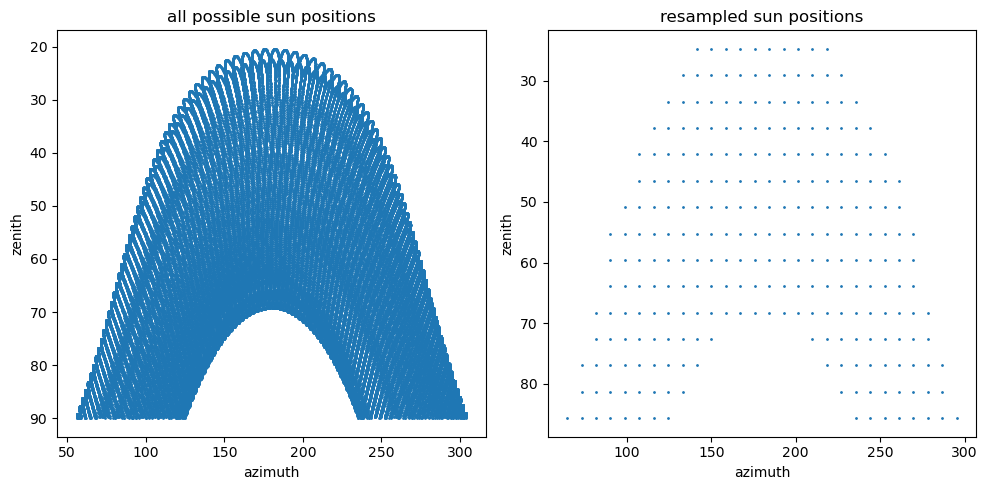

In [5]:
spgrid.plot_sunpositions()

Next, we create our database of sun-positions. For this example, the DEM is too large to fit all sun-position correction layers in memory so we will iteratively write out the results to a zarr store that can quickly be referenced later.

In [6]:
spgrid.calculate_terrain_corrections(output='zarr', outpth='D:/GitHub/insolpy/ExampleXX.zarr')

In [7]:
spgrid.corrections

<xarray.Dataset> Size: 72GB
Dimensions:            (azimuth: 28, column: 3102, row: 6923, zenith: 15)
Coordinates:
  * azimuth            (azimuth) float64 224B 64.56 73.11 81.65 ... 286.7 295.3
  * column             (column) int32 12kB 0 1 2 3 4 ... 3098 3099 3100 3101
  * row                (row) int32 28kB 0 1 2 3 4 5 ... 6918 6919 6920 6921 6922
  * zenith             (zenith) float64 120B 24.77 29.12 33.47 ... 81.3 85.65
Data variables:
    correction_factor  (row, column, azimuth, zenith) float64 72GB dask.array<chunksize=(433, 388, 4, 2), meta=np.ndarray>
Attributes:
    azimuth_res:  8
    bounds:       [-1182373.681795198, 2409482.226603891, -1089310.61972022, ...
    crs:          PROJCS["NAD83(HARN) / Conus Albers",GEOGCS["NAD83(HARN)",DA...
    resolution:   [30.000987129264313, -30.00112822040645]
    transform:    [30.000987129264313, 0.0, -1182373.681795198, 0.0, -30.0011...
    zenith_res:   4